<a href="https://colab.research.google.com/github/jspanchu/4961_hw1/blob/main/hw1_q5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

y = torch.tensor(range(1, 11)).unsqueeze(1)
X = y ** 7

In [ ]:
X,y


(tensor([[       1],
         [     128],
         [    2187],
         [   16384],
         [   78125],
         [  279936],
         [  823543],
         [ 2097152],
         [ 4782969],
         [10000000]]),
 tensor([[ 1],
         [ 2],
         [ 3],
         [ 4],
         [ 5],
         [ 6],
         [ 7],
         [ 8],
         [ 9],
         [10]]))

In [ ]:
X = X.to(torch.float32)
y = y.to(torch.float32)

# Transform the problem into log space to establish a linear relation ship
# that makes it easier for our nn to predict 7th root.
X_log = torch.log(X)
y_log = torch.log(y)

model = torch.nn.Sequential(
    torch.nn.Linear(1, 6),
    torch.nn.ReLU(),
    torch.nn.Linear(6, 6),
    torch.nn.ReLU(),
    torch.nn.Linear(6, 6),
    torch.nn.ReLU(),
    torch.nn.Linear(6, 1)
)
optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)
loss_fn = torch.nn.MSELoss(reduction='sum')

train_dataset = torch.utils.data.TensorDataset(X_log, y_log)
loader = torch.utils.data.DataLoader(train_dataset, batch_size=10, shuffle=True)

model.train()
for epoch in range(300):
  for X_batch, y_batch in loader:
    y_pred = model(X_batch)
    loss = loss_fn(y_pred, y_batch)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

model.eval()

def compute_prediction(inputs):
  with torch.no_grad():
    predictions_log = model(torch.log(inputs)).detach()
    predictions = torch.exp(predictions_log)
    return predictions

predictions = compute_prediction(X)
for i in range(10):
  print(f"{X[i].tolist()} => {predictions[i][0]:.2f} (expected {y[i][0]:.2f})")


[1.0] => 0.99 (expected 1.00)
[128.0] => 1.99 (expected 2.00)
[2187.0] => 3.05 (expected 3.00)
[16384.0] => 4.04 (expected 4.00)
[78125.0] => 5.03 (expected 5.00)
[279936.0] => 6.01 (expected 6.00)
[823543.0] => 6.98 (expected 7.00)
[2097152.0] => 7.95 (expected 8.00)
[4782969.0] => 8.92 (expected 9.00)
[10000000.0] => 9.89 (expected 10.00)


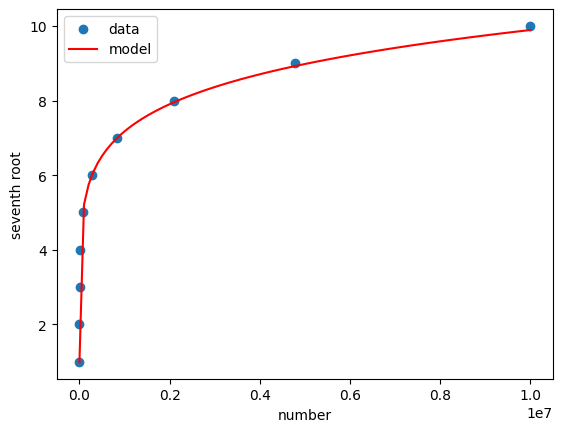

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
number_grid = np.linspace(1, 1e7, 100, dtype=np.float32)
plt.scatter(X,y, label='data')
predictions = compute_prediction(torch.tensor(number_grid).unsqueeze(1)).detach().numpy()
plt.plot(number_grid,predictions, color='red', label='model')
plt.xlabel('number')
plt.ylabel('seventh root')
plt.legend()